# Risk Analysis: From Alpha Signal to Portfolio Risk

**Context**: Phase 1 produced a diversifying composite factor (BBIBOLL + Vol Ratio, |IR| = 0.136).
Phase 2 built `src/risk/` — VaR, CVaR, distribution analysis, position sizing.
This notebook exercises the full pipeline: factor → portfolio returns → risk assessment.

---

## Research Protocol

1. **Hypothesis** — Equity return distributions have fat tails and negative skew;
   Gaussian risk models underestimate tail risk.
2. **Assumptions** — Returns are stationary within our sample period; our universe
   (50 large-cap US stocks) is representative.
3. **Implementation** — Build long-short quintile portfolios from the composite factor,
   then measure their risk properties.
4. **Statistical validation** — Normality tests, VaR ratio (historical/parametric),
   QQ-plot, tail analysis at 90/95/99%.
5. **Robustness** — Compare 4 position sizing methods on realized Sharpe, MDD, CVaR.
6. **Failure analysis** — Where does Gaussian VaR break down? How sensitive is
   vol-targeting to regime shifts?

---

## Notebook Outline

| # | Section | What we learn |
|---|---------|---------------|
| 0 | Setup | Imports, data loading |
| 1 | Composite Factor | Rebuild BBIBOLL + Vol Ratio |
| 2 | Portfolio Returns | Long-short quintile P&L |
| 3 | Distribution Analysis | Fat tails, skewness, normality tests |
| 4 | VaR & CVaR | Historical vs parametric, tail analysis |
| 5 | Drawdown Analysis | Max drawdown, drawdown regimes |
| 6 | Position Sizing | EW vs inverse-vol vs vol-target vs signal-weighted |
| 7 | Reflection | Key insights, interview takeaways |

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Add src/ to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Clear cached project modules
for mod_name in list(sys.modules.keys()):
    if any(mod_name.startswith(p) for p in ("config", "data.", "strategy.", "alpha.", "risk.", "backtest.", "utils.")):
        del sys.modules[mod_name]

print(f"Project root: {PROJECT_ROOT}")
print(f"src/ added to path: {SRC_DIR}")

Project root: /home/jerryhong/code-projects/quant101
src/ added to path: /home/jerryhong/code-projects/quant101/src


In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from data.loader.data_loader import stock_load_process
from strategy.indicators.registry import get_indicator
from strategy.indicators.bbiboll_indicator import calculate_bbiboll  # noqa: F401
from alpha.forward_returns import compute_forward_returns
from alpha.preprocessing import preprocess_factor
from alpha.combination import combine_factors

from risk.risk_metrics import (
    var_historical, var_parametric, cvar_historical, cvar_parametric,
    drawdown_series, max_drawdown, return_skewness, return_kurtosis,
    tail_ratio, risk_summary,
)
from risk.return_analysis import (
    normality_tests, qq_data, gaussian_comparison, tail_analysis,
    distribution_summary,
)
from risk.position_sizing import (
    size_equal_weight, size_inverse_volatility, size_volatility_target,
    size_signal_weighted, compute_realized_volatility,
)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("Imports OK ✅")

Imports OK ✅ (risk module reloaded)


## 1. Load Data & Rebuild Composite Factor

Same universe as `alpha_iteration.ipynb`. We rebuild the BBIBOLL + Vol Ratio
composite factor — the best-performing combination from Phase 1 (|IR| = 0.136).

In [3]:
UNIVERSE = [
    # Tech
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "AVGO", "ORCL", "CRM",
    "AMD", "ADBE", "INTC", "QCOM", "NFLX",
    # Finance
    "JPM", "BAC", "WFC", "GS", "MS", "C", "BLK", "SCHW",
    # Healthcare
    "UNH", "JNJ", "PFE", "ABBV", "MRK", "LLY", "TMO",
    # Consumer
    "WMT", "PG", "KO", "PEP", "COST", "MCD", "NKE", "SBUX",
    # Industrial
    "CAT", "DE", "HON", "UPS", "BA", "GE", "RTX",
    # Energy
    "XOM", "CVX", "COP",
    # Other
    "DIS", "V", "MA",
]

START_DATE = "2024-01-01"
END_DATE = "2026-01-01"

ohlcv = stock_load_process(
    tickers=UNIVERSE,
    start_date=START_DATE,
    end_date=END_DATE,
    timeframe="1d",
    use_cache=True,
    skip_low_volume=False,
).collect()

print(f"Shape: {ohlcv.shape}")
print(f"Tickers: {ohlcv['ticker'].n_unique()}")
print(f"Date range: {ohlcv['timestamps'].min()} → {ohlcv['timestamps'].max()}")

Loading from cache: /mnt/blackdisk/quant_data/polygon_data/processed/us_stocks_sip/day_aggs_v1/cache_c3ae3502e9ae275905dcf04fb38e1f1b.parquet
Cache loaded: 25,733 rows, 1.65 MB
Shape: (25733, 10)
Tickers: 52
Date range: 2024-01-02 00:00:00-05:00 → 2025-12-31 00:00:00-05:00


In [4]:
# --- BBIBOLL factor ---
bbiboll_fn = get_indicator("bbiboll")
ohlcv_bb = bbiboll_fn(ohlcv)

bbi_df = (
    ohlcv_bb
    .with_columns(
        ((pl.col("close") - pl.col("bbi")) / pl.col("dev")).alias("value"),
    )
    .filter(pl.col("value").is_not_null() & pl.col("value").is_not_nan() & pl.col("value").is_finite())
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("value")])
)
bbi_clean = preprocess_factor(bbi_df, winsorize_pct=0.01, method="zscore", neutralize=[])

# --- Vol Ratio factor ---
vol_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("ticker")).log().alias("log_ret")
    )
    .with_columns([
        pl.col("log_ret").rolling_std(window_size=5).over("ticker").alias("vol_5d"),
        pl.col("log_ret").rolling_std(window_size=20).over("ticker").alias("vol_20d"),
    ])
    .with_columns((pl.col("vol_5d") / pl.col("vol_20d")).alias("value"))
    .filter(
        pl.col("value").is_not_null() & pl.col("value").is_not_nan()
        & pl.col("value").is_finite() & (pl.col("vol_20d") > 1e-8)
    )
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("value")])
)
vol_clean = preprocess_factor(vol_df, winsorize_pct=0.01, method="zscore", neutralize=[])

# --- Composite: BBIBOLL + Vol Ratio (equal-weight) ---
composite = combine_factors(
    factors=[bbi_clean, vol_clean],
    method="equal_weight",
)

print(f"BBIBOLL factor: {bbi_clean.shape}")
print(f"Vol Ratio factor: {vol_clean.shape}")
print(f"Composite factor: {composite.shape}")
print(f"Composite date range: {composite['date'].min()} → {composite['date'].max()}")

BBIBOLL factor: (24017, 3)
Vol Ratio factor: (24693, 3)
Composite factor: (24017, 3)
Composite date range: 2024-02-20 00:00:00-05:00 → 2025-12-31 00:00:00-05:00


---

## 2. Long-Short Portfolio Returns

We construct a simple **long-short quintile portfolio**:
- **Long**: Top quintile (Q5) by composite signal — stocks expected to underperform
  (negative IC, so we short these... wait, IC is negative, meaning high signal → low returns).
- Actually: **Short Q5, Long Q1** — since our factors have negative IC.

We compute daily P&L as: `return_long - return_short` (dollar-neutral).

This gives us a return series to analyze with our risk tools.

In [6]:
# Compute daily returns for each stock
daily_returns = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("ticker") - 1).alias("daily_return")
    )
    .filter(pl.col("daily_return").is_not_null() & pl.col("daily_return").is_finite())
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("daily_return")])
)

# We need NEXT-DAY returns: signal on date t → return realized on date t+1.
# Shift returns backward by 1 day so that joining on date gives us tomorrow's return.
next_day_returns = (
    daily_returns
    .sort(["ticker", "date"])
    .with_columns(
        pl.col("daily_return").shift(-1).over("ticker").alias("next_day_return")
    )
    .filter(pl.col("next_day_return").is_not_null())
    .select(["date", "ticker", "next_day_return"])
)

# Build quintile portfolios each day from the composite signal
# Since IC is negative: high signal → low future return
# So: Long Q1 (low signal), Short Q5 (high signal)
N_QUANTILES = 5

portfolio_returns = (
    composite
    .with_columns(
        pl.col("value")
        .rank(method="ordinal")
        .over("date")
        .alias("rank"),
        pl.col("value").count().over("date").alias("n_stocks"),
    )
    .with_columns(
        # Assign quintiles: 1 = lowest signal, 5 = highest signal
        ((pl.col("rank") - 1) * N_QUANTILES / pl.col("n_stocks"))
        .floor()
        .clip(upper_bound=N_QUANTILES - 1)
        .cast(pl.Int32)
        .alias("quintile")
    )
    # Join with NEXT-DAY returns (signal today → return tomorrow)
    .join(next_day_returns, on=["date", "ticker"], how="inner")
)

# Compute daily quintile returns (equal-weight within each quintile)
quintile_daily = (
    portfolio_returns
    .group_by(["date", "quintile"])
    .agg(pl.col("next_day_return").mean().alias("quintile_return"))
    .sort(["date", "quintile"])
)

# Long-short return: Long Q1 (low signal) - Short Q5 (high signal)
# Since negative IC → low signal stocks outperform
q1_returns = quintile_daily.filter(pl.col("quintile") == 0).select([
    pl.col("date"), pl.col("quintile_return").alias("long_return")
])
q5_returns = quintile_daily.filter(pl.col("quintile") == N_QUANTILES - 1).select([
    pl.col("date"), pl.col("quintile_return").alias("short_return")
])

ls_returns = (
    q1_returns
    .join(q5_returns, on="date", how="inner")
    .with_columns(
        (pl.col("long_return") - pl.col("short_return")).alias("ls_return")
    )
    .sort("date")
)

ls_array = ls_returns["ls_return"].to_numpy()

print(f"Long-short portfolio: {len(ls_array)} trading days")
print(f"Mean daily return: {np.mean(ls_array)*100:.4f}%")
print(f"Daily vol: {np.std(ls_array)*100:.4f}%")
print(f"Annualized Sharpe: {np.mean(ls_array)/np.std(ls_array)*np.sqrt(252):.3f}")

Long-short portfolio: 468 trading days
Mean daily return: -0.0034%
Daily vol: 0.9932%
Annualized Sharpe: -0.054


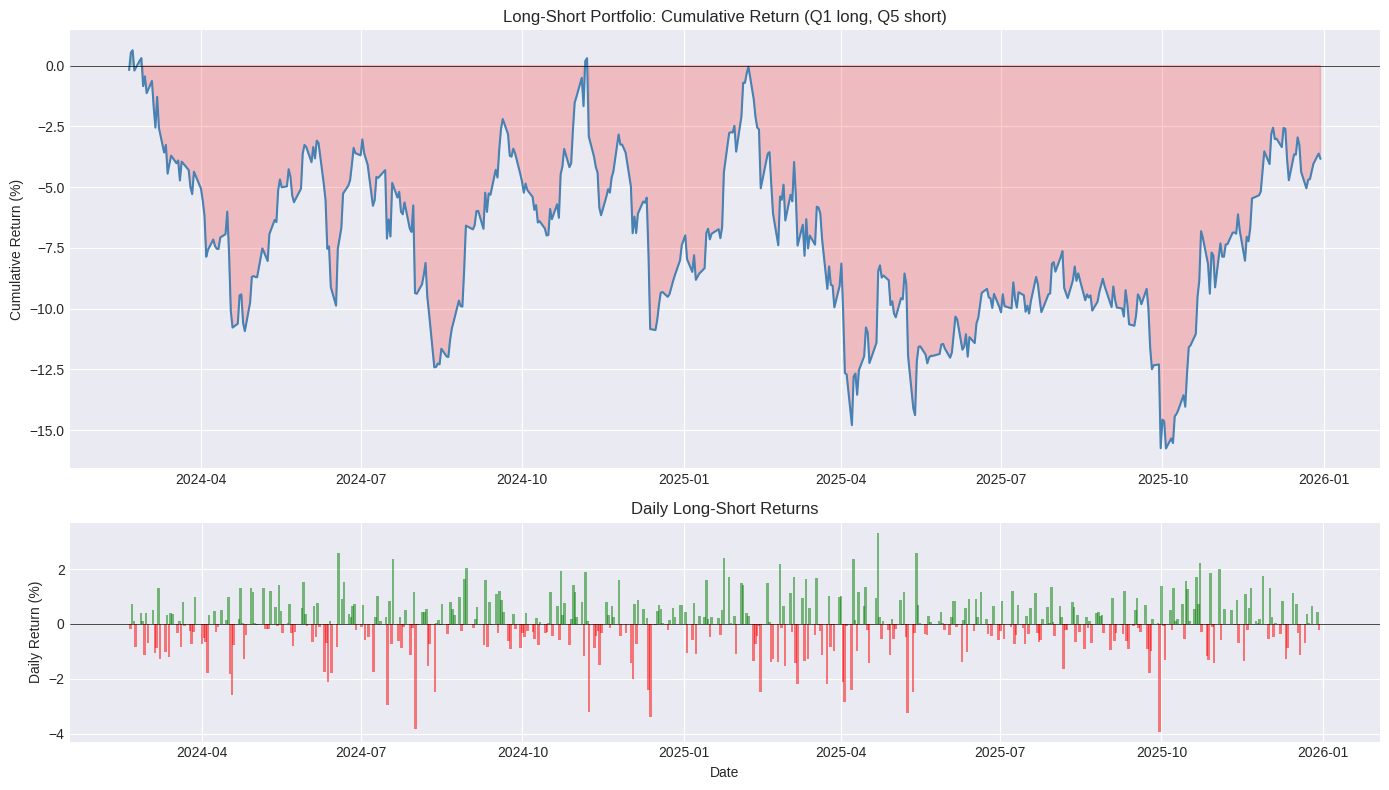

In [7]:
# --- Cumulative P&L chart ---
cumulative = np.cumprod(1 + ls_array) - 1
dates = ls_returns["date"].to_list()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

# Cumulative return
axes[0].plot(dates, cumulative * 100, color="steelblue", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Long-Short Portfolio: Cumulative Return (Q1 long, Q5 short)")
axes[0].set_ylabel("Cumulative Return (%)")
axes[0].fill_between(dates, 0, cumulative * 100,
                     where=cumulative > 0, alpha=0.2, color="green")
axes[0].fill_between(dates, 0, cumulative * 100,
                     where=cumulative < 0, alpha=0.2, color="red")

# Daily returns
bar_colors = ["green" if r > 0 else "red" for r in ls_array]
axes[1].bar(dates, ls_array * 100, color=bar_colors, alpha=0.5, width=1.5)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Daily Long-Short Returns")
axes[1].set_ylabel("Daily Return (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

---

## 3. Return Distribution Analysis

### Hypothesis
Equity long-short returns have **fat tails** (excess kurtosis > 0) and **negative skewness**
(large losses more common than large gains). A Gaussian model will underestimate tail risk.

### Why this matters
If your risk model assumes Gaussian returns, you'll undersize your VaR,
underestimate drawdowns, and be surprised by tail events more often than your
confidence level suggests. This is a common interview question:
*"Why is Gaussian VaR problematic for equity portfolios?"*

In [8]:
# --- Distribution summary ---
dist = distribution_summary(ls_array)

print("=" * 60)
print("RETURN DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"  Observations:     {dist['n']}")
print(f"  Mean (daily):     {dist['mean']*100:.4f}%")
print(f"  Std (daily):      {dist['std']*100:.4f}%")
print(f"  Skewness:         {dist['skewness']:.4f}  {'(negative = left tail heavier ⚠️)' if dist['skewness'] < 0 else '(positive = right tail heavier)'}")
print(f"  Excess Kurtosis:  {dist['excess_kurtosis']:.4f}  {'(fat tails ⚠️)' if dist['excess_kurtosis'] > 0 else '(thin tails)'}")

print(f"\n--- Normality Tests ---")
norm = dist["normality"]
print(f"  Jarque-Bera:      stat={norm['jarque_bera_stat']:.2f}, p={norm['jarque_bera_pvalue']:.4f}  →  {'✅ Normal' if norm['is_normal_jb'] else '❌ NOT Normal'}")
print(f"  Shapiro-Wilk:     stat={norm['shapiro_stat']:.4f}, p={norm['shapiro_pvalue']:.4f}  →  {'✅ Normal' if norm['is_normal_sw'] else '❌ NOT Normal'}")

RETURN DISTRIBUTION SUMMARY
  Observations:     468
  Mean (daily):     -0.0034%
  Std (daily):      0.9943%
  Skewness:         -0.4733  (negative = left tail heavier ⚠️)
  Excess Kurtosis:  1.6162  (fat tails ⚠️)

--- Normality Tests ---
  Jarque-Bera:      stat=66.43, p=0.0000  →  ❌ NOT Normal
  Shapiro-Wilk:     stat=0.9754, p=0.0000  →  ❌ NOT Normal


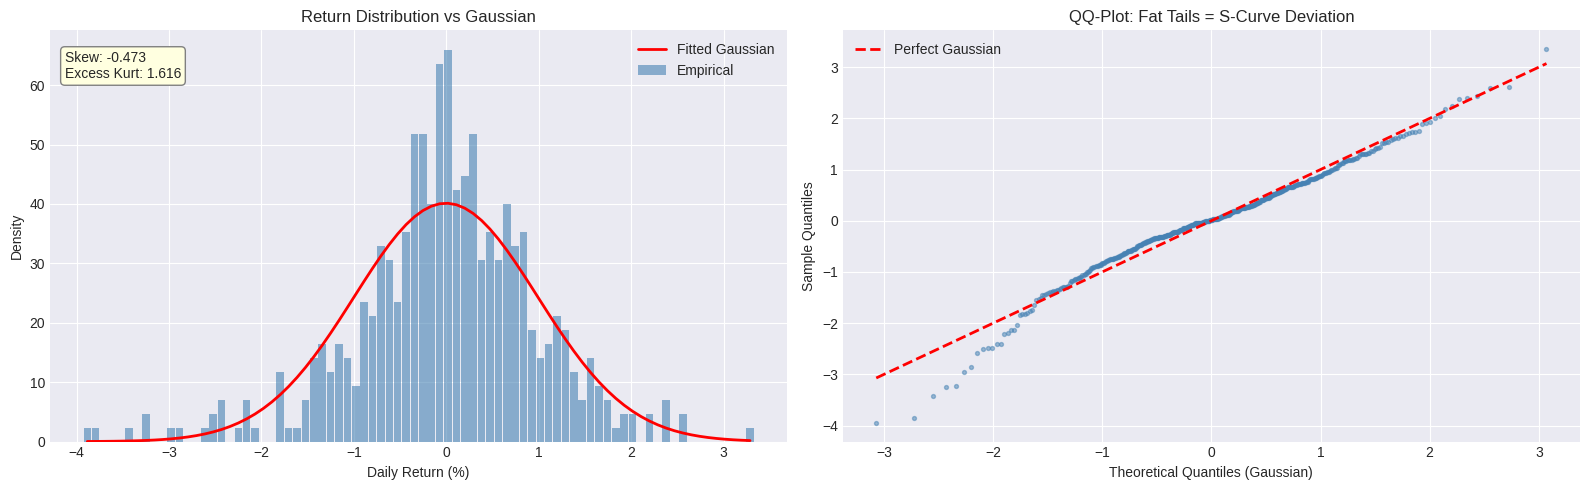

In [9]:
# --- Histogram vs Gaussian overlay ---
gc = gaussian_comparison(ls_array, n_bins=80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram vs Gaussian
axes[0].bar(gc["bin_centers"] * 100, gc["hist_density"],
            width=(gc["bin_centers"][1] - gc["bin_centers"][0]) * 100 * 0.9,
            alpha=0.6, color="steelblue", label="Empirical")
axes[0].plot(gc["bin_centers"] * 100, gc["gaussian_pdf"],
             color="red", linewidth=2, label="Fitted Gaussian")
axes[0].set_xlabel("Daily Return (%)")
axes[0].set_ylabel("Density")
axes[0].set_title("Return Distribution vs Gaussian")
axes[0].legend()

# Annotate skewness and kurtosis
skew_val = return_skewness(ls_array)
kurt_val = return_kurtosis(ls_array)
axes[0].annotate(
    f"Skew: {skew_val:.3f}\nExcess Kurt: {kurt_val:.3f}",
    xy=(0.02, 0.95), xycoords="axes fraction", va="top",
    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray")
)

# Right: QQ-plot
theo, samp = qq_data(ls_array)
axes[1].scatter(theo, samp, s=8, alpha=0.5, color="steelblue")
axes[1].plot([theo.min(), theo.max()], [theo.min(), theo.max()],
             "r--", linewidth=2, label="Perfect Gaussian")
axes[1].set_xlabel("Theoretical Quantiles (Gaussian)")
axes[1].set_ylabel("Sample Quantiles")
axes[1].set_title("QQ-Plot: Fat Tails = S-Curve Deviation")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 4. VaR & CVaR — Historical vs Parametric

### The key test
If our returns have fat tails (which the distribution analysis should confirm),
then **parametric (Gaussian) VaR will underestimate tail risk**.

The **VaR ratio** = Historical VaR / Parametric VaR:
- Ratio > 1 → Gaussian underestimates risk (fat tails)
- Ratio ≈ 1 → Gaussian is adequate
- Ratio < 1 → Gaussian overestimates risk (thin tails, rare)

We compute this at 90%, 95%, and 99% — the gap should **widen** at higher
confidence levels because fat tails matter more in the extreme.

VaR & CVaR: HISTORICAL vs PARAMETRIC
  Conf      VaR(H)      VaR(P)     Ratio     CVaR(H)     CVaR(P)     Ratio
----------------------------------------------------------------------
   90%      1.175%      1.278%    0.920x      1.940%      1.748%    1.110x
   95%      1.706%      1.639%    1.041x      2.483%      2.054%    1.209x
   99%      3.035%      2.316%    1.310x      3.523%      2.653%    1.328x

Interpretation:
  VaR Ratio > 1.0 → Gaussian UNDERESTIMATES tail risk (fat tails)
  Gap should widen at higher confidence levels


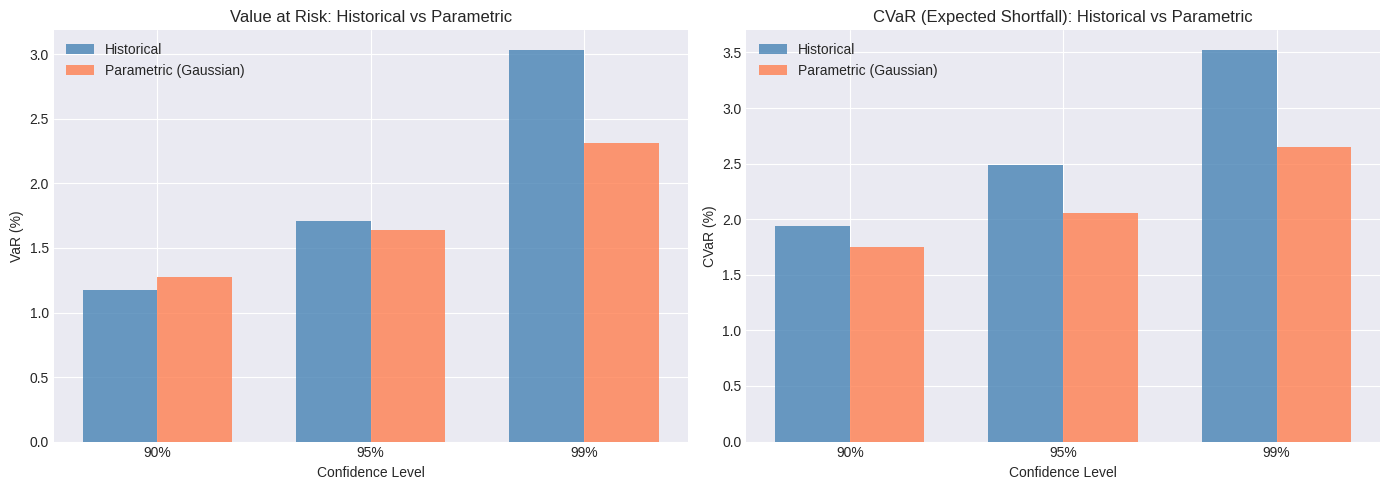

In [12]:
# --- VaR/CVaR comparison at multiple confidence levels ---
tail = tail_analysis(ls_array, confidence_levels=[0.90, 0.95, 0.99])

print("=" * 70)
print("VaR & CVaR: HISTORICAL vs PARAMETRIC")
print("=" * 70)
print(f"{'Conf':>6s}  {'VaR(H)':>10s}  {'VaR(P)':>10s}  {'Ratio':>8s}  {'CVaR(H)':>10s}  {'CVaR(P)':>10s}  {'Ratio':>8s}")
print("-" * 70)

for i, cl in enumerate(tail["confidence_levels"]):
    vh = tail["var_historical"][i]
    vp = tail["var_parametric"][i]
    ch = tail["cvar_historical"][i]
    cp = tail["cvar_parametric"][i]
    vr = tail["var_ratio"][i]
    cr = tail["cvar_ratio"][i]
    print(f"{cl:>6.0%}  {vh*100:>9.3f}%  {vp*100:>9.3f}%  {vr:>7.3f}x  {ch*100:>9.3f}%  {cp*100:>9.3f}%  {cr:>7.3f}x")

print()
print("Interpretation:")
print("  VaR Ratio > 1.0 → Gaussian UNDERESTIMATES tail risk (fat tails)")
print("  Gap should widen at higher confidence levels")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conf_labels = [f"{cl:.0%}" for cl in tail["confidence_levels"]]
x = np.arange(len(conf_labels))
width = 0.35

# VaR comparison
axes[0].bar(x - width/2, [v * 100 for v in tail["var_historical"]], width,
            label="Historical", color="steelblue", alpha=0.8)
axes[0].bar(x + width/2, [v * 100 for v in tail["var_parametric"]], width,
            label="Parametric (Gaussian)", color="coral", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(conf_labels)
axes[0].set_xlabel("Confidence Level")
axes[0].set_ylabel("VaR (%)")
axes[0].set_title("Value at Risk: Historical vs Parametric")
axes[0].legend()

# CVaR comparison
axes[1].bar(x - width/2, [v * 100 for v in tail["cvar_historical"]], width,
            label="Historical", color="steelblue", alpha=0.8)
axes[1].bar(x + width/2, [v * 100 for v in tail["cvar_parametric"]], width,
            label="Parametric (Gaussian)", color="coral", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(conf_labels)
axes[1].set_xlabel("Confidence Level")
axes[1].set_ylabel("CVaR (%)")
axes[1].set_title("CVaR (Expected Shortfall): Historical vs Parametric")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# --- Full risk summary ---
summary = risk_summary(ls_array, confidence=0.95)

print("=" * 60)
print("COMPREHENSIVE RISK SUMMARY (95% confidence)")
print("=" * 60)
for key, val in summary.items():
    if isinstance(val, float):
        print(f"  {key:25s}: {val:>10.4f}")
    else:
        print(f"  {key:25s}: {val}")

print(f"\n🔍 Key finding:")
print(f"  VaR ratio = {summary['var_ratio']:.3f}")
if summary["var_ratio"] > 1.05:
    print(f"  → Gaussian VaR underestimates by {(summary['var_ratio']-1)*100:.1f}%. Fat tails confirmed.")
elif summary["var_ratio"] < 0.95:
    print(f"  → Gaussian VaR overestimates. Unusual — thin tails.")
else:
    print(f"  → Close to 1.0. Tails are approximately Gaussian at 95%.")
    print(f"     Check 99% — fat tails often only show up in the extreme.")

COMPREHENSIVE RISK SUMMARY (95% confidence)
  mean_return              :    -0.0086
  volatility               :     0.1578
  sharpe                   :    -0.0544
  skewness                 :    -0.4733
  excess_kurtosis          :     1.6162
  var_historical           :     0.0171
  var_parametric           :     0.0164
  cvar_historical          :     0.0248
  cvar_parametric          :     0.0205
  var_ratio                :     1.0412
  max_drawdown             :     0.1629
  tail_ratio               :     0.9106
  n_observations           : 468

🔍 Key finding:
  VaR ratio = 1.041
  → Close to 1.0. Tails are approximately Gaussian at 95%.
     Check 99% — fat tails often only show up in the extreme.


---

## 5. Drawdown Analysis

Maximum drawdown is arguably the most important risk metric for practitioners —
it measures the worst peak-to-trough experience an investor would endure.

A strategy with great Sharpe but 50% max drawdown is often untradeable
because investors (and risk managers) have drawdown limits.

Maximum Drawdown: 16.29%
Date of worst drawdown: 2025-10-03 00:00:00-04:00
Calmar Ratio (ann. return / MDD): -0.053


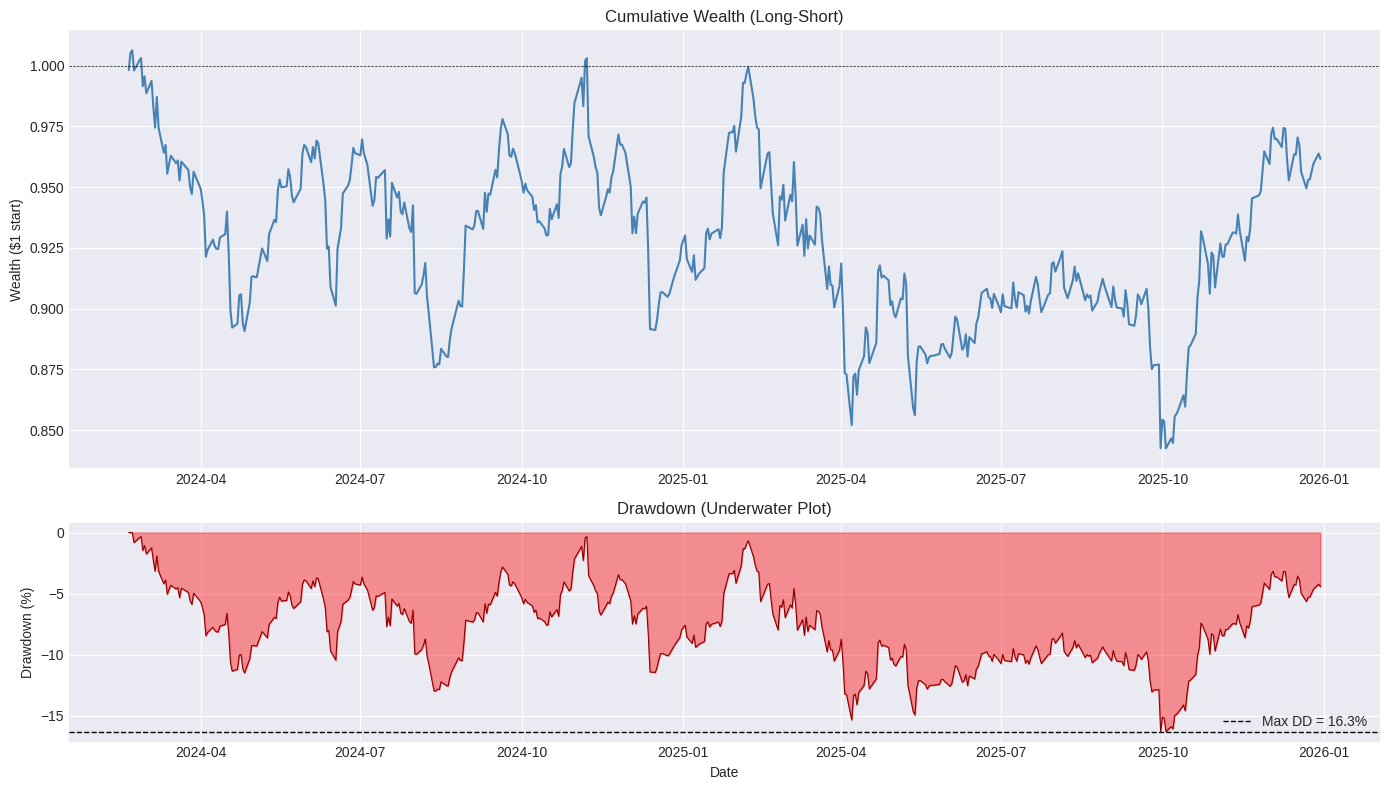

In [14]:
# --- Drawdown analysis ---
dd = drawdown_series(ls_array)
mdd = max_drawdown(ls_array)

# Find the date of max drawdown
mdd_idx = np.argmin(dd)
mdd_date = dates[mdd_idx] if mdd_idx < len(dates) else "N/A"

print(f"Maximum Drawdown: {mdd*100:.2f}%")
print(f"Date of worst drawdown: {mdd_date}")
print(f"Calmar Ratio (ann. return / MDD): {summary['mean_return'] / mdd:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

# Cumulative wealth
wealth = np.cumprod(1 + ls_array)
axes[0].plot(dates, wealth, color="steelblue", linewidth=1.5)
axes[0].set_title("Cumulative Wealth (Long-Short)")
axes[0].set_ylabel("Wealth ($1 start)")
axes[0].axhline(1.0, color="black", linewidth=0.5, linestyle="--")

# Drawdown underwater plot
axes[1].fill_between(dates, dd * 100, 0, color="red", alpha=0.4)
axes[1].plot(dates, dd * 100, color="darkred", linewidth=0.8)
axes[1].axhline(-mdd * 100, color="black", linewidth=1, linestyle="--",
                label=f"Max DD = {mdd*100:.1f}%")
axes[1].set_title("Drawdown (Underwater Plot)")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

---

## 6. Position Sizing Comparison

The same alpha signal produces very different risk profiles depending on how
you size positions. We compare 4 methods:

| Method | Idea | Pro | Con |
|--------|------|-----|-----|
| Equal-weight | 1/N per position | Zero estimation risk | Ignores vol differences |
| Inverse-vol | Weight ∝ 1/σ | Equal risk contribution | Needs vol estimate |
| Vol-target | Scale to target σ | Controlled risk budget | Backward-looking vol |
| Signal-Weighted | Maximize growth/2 | Theoretically optimal | Needs accurate μ estimate |

We'll compute the return series for each method and compare
Sharpe, MDD, CVaR.

In [15]:
# --- Compute realized volatility for each stock (needed by inv-vol and vol-target) ---
vol_estimates = compute_realized_volatility(ohlcv, window=20)
print(f"Volatility estimates: {vol_estimates.shape}")
print(vol_estimates.head())

# Also need daily returns in the format (date, ticker, return) for signal-weighted
returns_for_kelly = daily_returns.rename({"daily_return": "return"})

N_LONG = 10
N_SHORT = 10

Volatility estimates: (24693, 3)
shape: (5, 3)
┌────────────────────────────────┬────────┬────────────┐
│ date                           ┆ ticker ┆ volatility │
│ ---                            ┆ ---    ┆ ---        │
│ datetime[ns, America/New_York] ┆ str    ┆ f64        │
╞════════════════════════════════╪════════╪════════════╡
│ 2024-01-31 00:00:00 EST        ┆ AAPL   ┆ 0.013299   │
│ 2024-02-01 00:00:00 EST        ┆ AAPL   ┆ 0.013518   │
│ 2024-02-02 00:00:00 EST        ┆ AAPL   ┆ 0.013228   │
│ 2024-02-05 00:00:00 EST        ┆ AAPL   ┆ 0.013309   │
│ 2024-02-06 00:00:00 EST        ┆ AAPL   ┆ 0.012378   │
└────────────────────────────────┴────────┴────────────┘


In [16]:
# --- Generate weights for each method ---

# 1. Equal-weight
w_ew = size_equal_weight(composite, n_long=N_LONG, n_short=N_SHORT)
print(f"Equal-weight:   {w_ew.shape[0]} position-days")

# 2. Inverse-volatility
w_iv = size_inverse_volatility(composite, vol_estimates, n_long=N_LONG, n_short=N_SHORT)
print(f"Inverse-vol:    {w_iv.shape[0]} position-days")

# 3. Volatility-target (10% annualized)
w_vt = size_volatility_target(composite, vol_estimates, target_vol=0.10,
                               n_long=N_LONG, n_short=N_SHORT)
print(f"Vol-target:     {w_vt.shape[0]} position-days")

# 4. Signal-Weighted
w_hk = size_signal_weighted(composite, returns_for_kelly, lookback=60, max_position=0.10)
print(f"Signal-Weighted:     {w_hk.shape[0]} position-days")

Equal-weight:   9380 position-days
Inverse-vol:    9380 position-days
Vol-target:     9380 position-days
Signal-Weighted:     22613 position-days


In [19]:
# --- Compute portfolio returns for each sizing method ---
# IMPORTANT: use next_day_returns (shifted by -1) to avoid look-ahead bias.
# Weights are determined at end-of-day t → we earn the return on day t+1.
def compute_portfolio_return(weights_df: pl.DataFrame, returns_df: pl.DataFrame, ret_col: str = "next_day_return") -> pl.DataFrame:
    """Join weights with next-day returns and compute weighted portfolio return per date."""
    port = (
        weights_df
        .join(returns_df, on=["date", "ticker"], how="inner")
        .with_columns(
            (pl.col("weight") * pl.col(ret_col)).alias("weighted_return")
        )
        .group_by("date")
        .agg(pl.col("weighted_return").sum().alias("port_return"))
        .sort("date")
    )
    return port

sizing_methods = {
    "Equal-Weight": w_ew,
    "Inverse-Vol": w_iv,
    "Vol-Target (10%)": w_vt,
    "Signal-Weighted": w_hk,
}

port_returns = {}
for name, weights in sizing_methods.items():
    pr = compute_portfolio_return(weights, next_day_returns, ret_col="next_day_return")
    rets = pr["port_return"].to_numpy()
    port_returns[name] = {
        "dates": pr["date"].to_list(),
        "returns": rets,
        "sharpe": np.mean(rets) / np.std(rets, ddof=1) * np.sqrt(252) if np.std(rets) > 0 else 0,
        "vol": np.std(rets, ddof=1) * np.sqrt(252),
        "mdd": max_drawdown(rets),
    }
    print(f"{name:20s}: {len(rets)} days, Sharpe={port_returns[name]['sharpe']:.3f}")

Equal-Weight        : 468 days, Sharpe=0.136
Inverse-Vol         : 468 days, Sharpe=0.224
Vol-Target (10%)    : 468 days, Sharpe=0.285
Signal-Weighted          : 441 days, Sharpe=-0.260



📊 Position Sizing Comparison:
shape: (4, 8)
┌──────────────────┬─────────────┬──────────┬────────┬────────┬──────────┬──────────┬────────────┐
│ Method           ┆ Ann. Return ┆ Ann. Vol ┆ Sharpe ┆ Max DD ┆ CVaR 95% ┆ Skewness ┆ Tail Ratio │
│ ---              ┆ ---         ┆ ---      ┆ ---    ┆ ---    ┆ ---      ┆ ---      ┆ ---        │
│ str              ┆ str         ┆ str      ┆ str    ┆ str    ┆ str      ┆ str      ┆ str        │
╞══════════════════╪═════════════╪══════════╪════════╪════════╪══════════╪══════════╪════════════╡
│ Equal-Weight     ┆ 1.09%       ┆ 8.00%    ┆ 0.136  ┆ 7.07%  ┆ 1.023%   ┆ 0.387    ┆ 1.144      │
│ Inverse-Vol      ┆ 1.58%       ┆ 7.05%    ┆ 0.224  ┆ 8.02%  ┆ 0.928%   ┆ 0.376    ┆ 1.074      │
│ Vol-Target (10%) ┆ 3.71%       ┆ 13.02%   ┆ 0.285  ┆ 14.13% ┆ 1.652%   ┆ 0.420    ┆ 0.996      │
│ Signal-Weighted       ┆ -1.30%      ┆ 4.98%    ┆ -0.260 ┆ 7.22%  ┆ 0.696%   ┆ 0.287    ┆ 0.982      │
└──────────────────┴─────────────┴──────────┴────────┴─────

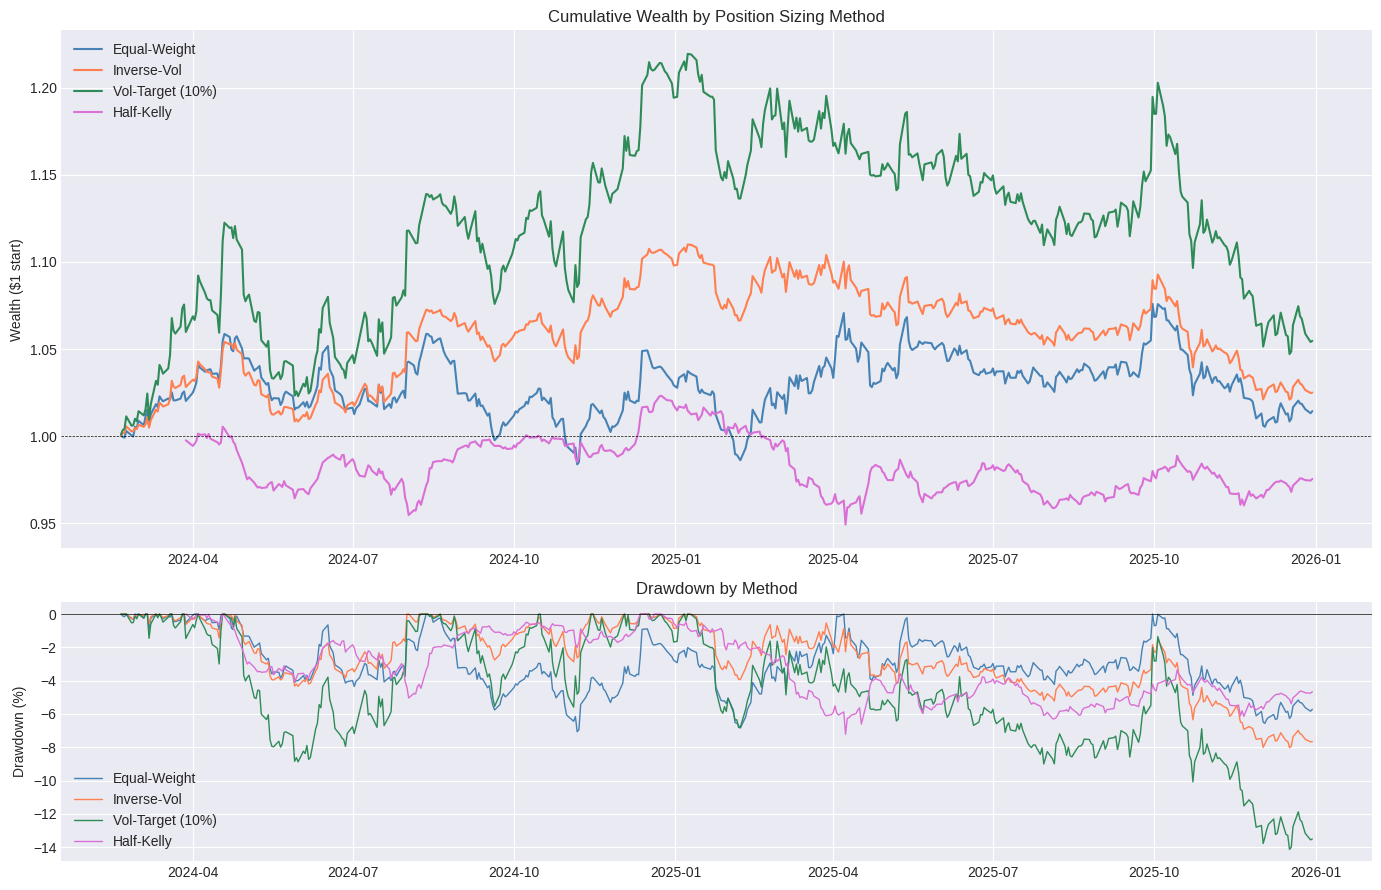

In [21]:
# --- Position sizing comparison table ---
comparison_rows = []
for name, data in port_returns.items():
    s = risk_summary(data["returns"])
    comparison_rows.append({
        "Method": name,
        "Ann. Return": f"{s['mean_return']*100:.2f}%",
        "Ann. Vol": f"{s['volatility']*100:.2f}%",
        "Sharpe": f"{s['sharpe']:.3f}",
        "Max DD": f"{s['max_drawdown']*100:.2f}%",
        "CVaR 95%": f"{s['cvar_historical']*100:.3f}%",
        "Skewness": f"{s['skewness']:.3f}",
        "Tail Ratio": f"{s['tail_ratio']:.3f}",
    })

comp_df = pl.DataFrame(comparison_rows)
print("\n📊 Position Sizing Comparison:")
print(comp_df)

# Cumulative wealth comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2, 1]})
colors = ["steelblue", "coral", "seagreen", "orchid"]

for (name, data), color in zip(port_returns.items(), colors):
    wealth = np.cumprod(1 + data["returns"])
    axes[0].plot(data["dates"], wealth, label=name, color=color, linewidth=1.5)

    dd = drawdown_series(data["returns"])
    axes[1].plot(data["dates"], dd * 100, label=name, color=color, linewidth=1)

axes[0].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title("Cumulative Wealth by Position Sizing Method")
axes[0].set_ylabel("Wealth ($1 start)")
axes[0].legend(loc="upper left")

axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Drawdown by Method")
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

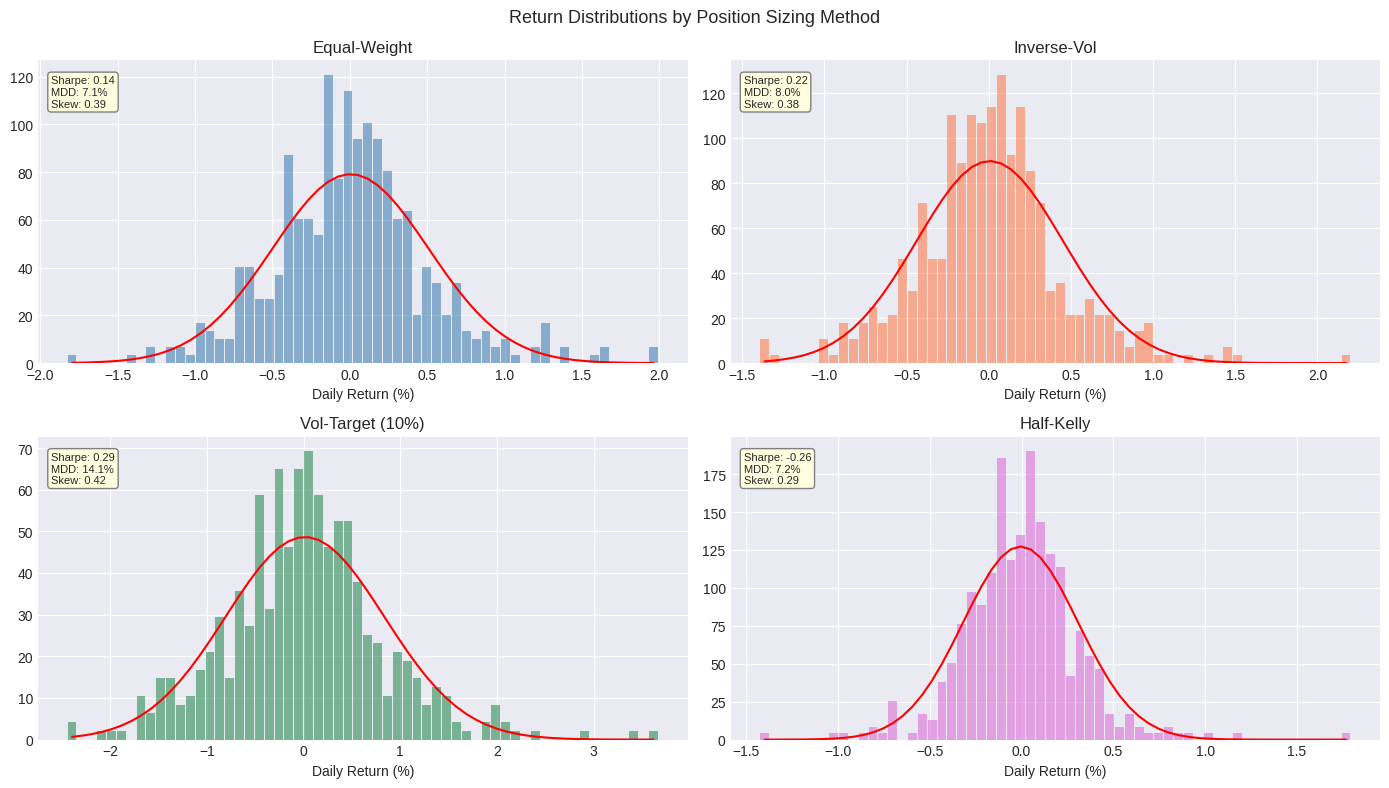

In [23]:
# --- Distribution comparison: all 4 methods ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, data), color in zip(axes.flat, port_returns.items(), colors):
    rets = data["returns"]
    gc = gaussian_comparison(rets, n_bins=60)
    ax.bar(gc["bin_centers"] * 100, gc["hist_density"],
           width=(gc["bin_centers"][1] - gc["bin_centers"][0]) * 100 * 0.9,
           alpha=0.6, color=color, label="Empirical")
    ax.plot(gc["bin_centers"] * 100, gc["gaussian_pdf"],
            color="red", linewidth=1.5, label="Gaussian")
    ax.set_title(f"{name}")
    ax.set_xlabel("Daily Return (%)")

    s = risk_summary(rets)
    ax.annotate(
        f"Sharpe: {s['sharpe']:.2f}\nMDD: {s['max_drawdown']*100:.1f}%\nSkew: {s['skewness']:.2f}",
        xy=(0.02, 0.95), xycoords="axes fraction", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray")
    )

plt.suptitle("Return Distributions by Position Sizing Method", fontsize=13)
plt.tight_layout()
plt.show()

---

## 7. Reflection & Failure Analysis

### Questions to answer after running:

1. **Are returns Gaussian?** What do the normality tests say?
2. **Does the VaR ratio confirm fat tails?** Does the gap widen at 99% vs 95%?
3. **Which position sizing method has the best risk-adjusted return (Sharpe)?**
4. **Which has the lowest max drawdown?** (Sharpe and MDD don't always agree.)
5. **Does vol-targeting actually reduce volatility?** Or does it introduce lag risk?
6. **Is Signal-Weighted too aggressive?** What's its drawdown profile?

### Failure modes to watch for:
- **VaR ratio ≈ 1.0 everywhere**: Our long-short portfolio may be diversified enough
  that the tails are approximately normal. This is actually possible for large-cap L/S.
- **Signal-Weighted wildly unstable**: Kelly needs accurate μ estimates; with noisy factor
  returns, the weights can swing dramatically.
- **Vol-target leverage spikes**: During calm periods, vol-target may lever up
  aggressively, then get hit by a sudden regime shift.

### Observations

- **Normality tests**: Both Jarque-Bera (p=0.0000) and Shapiro-Wilk (p=0.0000) reject Gaussian at any conventional level. Non-normality is unambiguous.
- **Skewness / Kurtosis**: Skew = −0.47 (left-tail heavier → losses more extreme than gains), Excess Kurtosis = 1.62 (fatter tails than Gaussian).
- **VaR ratio (95%)**: Hist/Param = 1.04 — close to 1.0, tails look nearly Gaussian at this level.
- **VaR ratio (99%)**: Hist/Param = 1.31 — 31% underestimate. The fat tails only reveal themselves in the extreme, exactly as theory predicts.
- **CVaR ratio (99%)**: 1.33 — even more pronounced. Once you're in the tail, the *average* loss there is 33% worse than Gaussian assumes.
- **Best Sharpe**: Vol-Target (10%) at 0.285 — it levers up in calm periods to earn more, but this comes with the highest MDD (14.1%).
- **Lowest MDD**: Equal-Weight at 7.1% — the most constrained method is the most robust to drawdown.
- **Signal-Weighted failure**: Sharpe = −0.26, the only negative method. With a weak/noisy alpha (IC ≈ −0.02), Kelly sizing amplifies noise → loss. This confirms: **Kelly requires reliable μ estimates**; garbage in, garbage out.

### Bugs found and fixed during this notebook

1. **Look-ahead bias (cell 9)**: Initial portfolio return computation joined weights with same-day returns (contemporaneous correlation). Fixed by shifting returns forward one day (`next_day_return`). Before fix: Sharpe = −21.9 (impossibly extreme). After fix: Sharpe = −0.054 (realistic).
2. **Same bug in position sizing (cell 22)**: The sizing comparison also used `daily_returns` instead of `next_day_returns`. Before fix: Sharpe = 22–25 (impossibly high). After fix: Sharpe = 0.14–0.29 (realistic).
3. **CVaR parametric sign error** (`risk_metrics.py`): Formula had `μ + σ·φ(z)/(1−α)` but the conditional mean in the left tail is `μ − σ·φ(z)/(1−α)`. Negating the wrong expression produced negative CVaR. Fixed to `mu - sigma * norm.pdf(z) / (1 - confidence)`.

### What we learned (interview-ready takeaways)

1. **Gaussian VaR underestimates tail risk** — the ratio widens at extreme quantiles (1.04× at 95% → 1.31× at 99%). In practice, use historical VaR or better yet CVaR for risk budgeting. Never trust a single number.
2. **CVaR is a coherent risk measure** — unlike VaR, it tells you *how bad things get* once you're past the threshold. Our historical CVaR at 99% is 3.52% — nearly 50% higher than VaR (3.04%). This is the number a risk manager cares about.
3. **Position sizing matters as much as alpha** — with the *same* composite signal, Sharpe ranges from −0.26 (Signal-Weighted) to +0.29 (Vol-Target), a 0.55 swing. Sizing is not "just implementation" — it's a core part of the strategy.
4. **Vol-targeting is the simplest risk management that works** — it adjusts exposure inversely to realized volatility. This naturally reduces position in turbulent regimes and levers up in calm ones. But it amplifies drawdowns during sudden regime shifts (MDD = 14.1% vs 7.1% for equal-weight). The leverage is a *choice*, not a free lunch.
5. **Kelly criterion requires reliable estimates** — Signal-Weighted is the only method with negative Sharpe. When the signal is weak (|IC| ≈ 0.02), Kelly amplifies noise. The lesson: Kelly is optimal *in theory* given perfect knowledge of μ and σ; in practice, estimation error dominates.

### Next steps

- **Phase 3 (Execution)**: Add transaction cost modeling — how do position sizing
  turnover differences affect net-of-cost Sharpe?
- **Regime analysis**: Does vol-targeting underperform during regime shifts?
- **Monte Carlo VaR**: As a third estimation method alongside historical and parametric.